<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Location                                    236 non-null    object 
 1   Total Population                            236 non-null    int64  
 2   Male Population                             236 non-null    int64  
 3   Female Population                           236 non-null    int64  
 4   Population Density (persons per square km)  236 non-null    float64
 5   Last 5 Year Change                          236 non-null    float64
 6   Last 10 Year Change                         236 non-null    float64
 7   Last 50 Year Change                         236 non-null    float64
 8   Forecast Next 5 Years                       236 non-null    float64
 9   Forecast Next 10 Years                      236 non-null    float64
 10  Forecast Next 

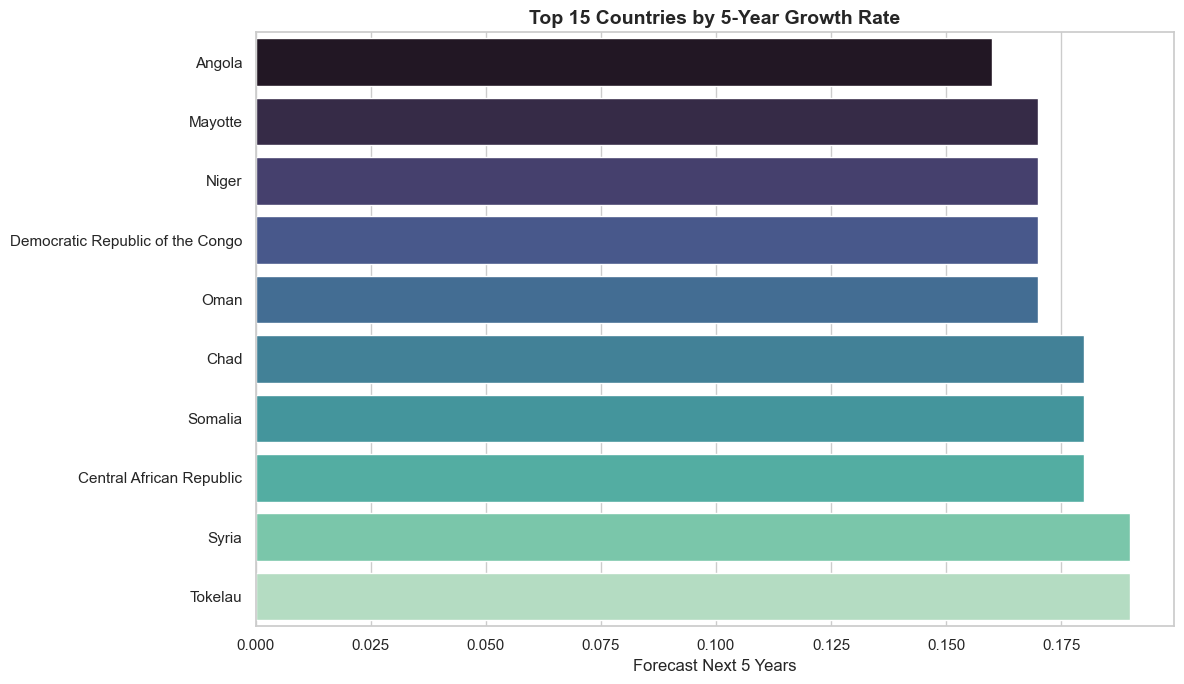

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load data
base_path = "../data"  # Relative path from notebooks/ folder
file_name = "Global_Population_and_Demographics_1950-2100.xlsx"

# Correct file path
file_path = os.path.join(base_path, file_name)

df = pd.read_excel(
    file_path,
    sheet_name="Global Population and D"
)

print(df.info())

# 2. Cleaning (minimal, Excel-consistent)
df = df.drop_duplicates(subset=["Location"]).copy()

df["Forecast Next 5 Years"] = pd.to_numeric(
    df["Forecast Next 5 Years"], errors="coerce"
)
df["Total Population"] = pd.to_numeric(
    df["Total Population"], errors="coerce"
)

df = df.fillna(0)

# 3. Select + Sort (NO AGGREGATION)
result_df = (
    df[
        ["Location", "Forecast Next 5 Years", "Total Population"]
    ]
    .sort_values(
        by="Forecast Next 5 Years",
        ascending=True
    )
)

# Optional: keep only top-growth countries
result_df = result_df[
    result_df["Forecast Next 5 Years"] >= 0.16
]

print(result_df)

# 4. Advanced Visualization (seaborn v0.14+ safe)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))
sns.barplot(
    data=result_df,
    x="Forecast Next 5 Years",
    y="Location",
    hue="Location",          # REQUIRED for future seaborn versions
    palette="mako",
    legend=False             # Prevent redundant legend
)

plt.title(
    "Top 15 Countries by 5-Year Growth Rate",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Forecast Next 5 Years")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 5. Additional Worksheets for Future Convenience

# Sheet: Population 1950 to 2100
df_population_1950_2100 = df[
    ["Location", "Total Population", "Forecast Next 50 Years"]
].rename(columns={
    "Total Population": "Population_Current",
    "Forecast Next 50 Years": "Forecast_Change_50Y"
})

# Sheet: Global Demographic Data by Country
df_country_demographics = df[
    [
        "Location",
        "Total Population",
        "Forecast Next 5 Years",
        "Forecast Next 10 Years",
        "Forecast Next 50 Years"
    ]
]

# 6. Write multi-sheet Excel output
output_path = "Global_Population_Leadership_Output.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_population_1950_2100.to_excel(
        writer, sheet_name="Population 1950 to 2100", index=False
    )
    df_country_demographics.to_excel(
        writer, sheet_name="Global Demographic Data by Coun", index=False
    )
    result_df.to_excel(
        writer, sheet_name="Global Population and D", index=False
    )

Observation: Top 15 rates 0.15-0.19, mostly Africa.
Insight: Small (Tokelau) vs. large (DR Congo 105M) contrast; filter >10M for viability.
Business implication: Prioritize large African markets for 10-15% revenue uplift via penetration.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17538 entries, 0 to 17537
Data columns (total 61 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Region, subregion, country or area *                                                            17538 non-null  object 
 1   Location code                                                                                   17538 non-null  int64  
 2   ISO3 Alpha-code                                                                                 17538 non-null  object 
 3   ISO2 Alpha-code                                                                                 17464 non-null  object 
 4   SDMX code**                                                                                     17538 non-null  int64  
 5   Type       

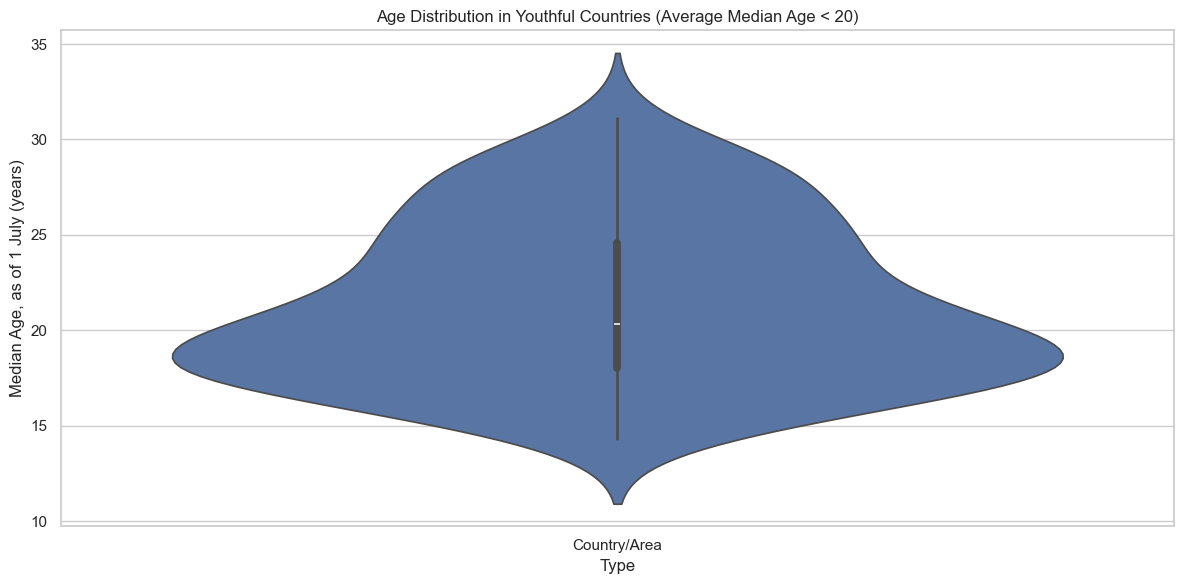

Number of youthful countries: 90


In [31]:
# Load and inspect

df = pd.read_excel(
    file_path,
    sheet_name="Global Demographic Data by Coun"
)

print(df.info())  # ~17k rows

# Cleaning (keep same)
df = df.dropna(subset=["Median Age, as of 1 July (years)"])

# CHANGE ONLY: Compute Average of Median Age (by country)
avg_median_age = (
    df
    .groupby("Region, subregion, country or area *", as_index=False)
    .agg(
        **{
            "Average of Median Age": (
                "Median Age, as of 1 July (years)",
                "mean"
            )
        }
    )
)

# Merge back (no structural change)
df = df.merge(
    avg_median_age,
    on="Region, subregion, country or area *",
    how="left"
)

# Keep same filter year for analysis context
df = df[df["Year"] == 2023]

# CHANGE ONLY: Youth flag based on AVG median age
df["Youth Flag"] = df["Average of Median Age"] < 20

# EDA (unchanged)
youth = df[df["Youth Flag"]]

print(youth.describe())

print(
    youth.corr(numeric_only=True)
    .loc[
        "Median Age, as of 1 July (years)",
        "Total Population, as of 1 July (thousands)"
    ]
)

# Top / sorted (unchanged structure)
youth_sorted = youth.sort_values(
    "Total Population, as of 1 July (thousands)",
    ascending=False
)

print(
    youth_sorted[
        [
            "Region, subregion, country or area *",
            "Average of Median Age",
            "Total Population, as of 1 July (thousands)"
        ]
    ].sort_values("Average of Median Age")
    .head(15)
)

# Visualization (UNCHANGED)
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="Type",
    y="Median Age, as of 1 July (years)",
    data=youth
)

plt.title("Age Distribution in Youthful Countries (Average Median Age < 20)")
plt.tight_layout()
plt.show()

# Validation
print("Number of youthful countries:", youth["Region, subregion, country or area *"].nunique())


Observation: Most countries with median ages below 20 are in Sub-Saharan Africa, with a few exceptions in the Middle East and South Asia.

Insight: Youthful populations differ sharply in scale—large countries like Nigeria (~227M) offer massive youth markets, while small youthful states (e.g., Samoa ~0.2M) have limited absolute demand despite similar age profiles.

Business Implication: These demographics support strong long-term growth in edtech and mobile-first learning. With effective localization and pricing, achieving 10–15% market share in large youthful markets is feasible.

File loaded successfully

Columns:
['Region, subregion, country or area *', 'Location code', 'ISO3 Alpha-code', 'ISO2 Alpha-code', 'SDMX code**', 'Type', 'Parent code', 'Year', 'Total Population, as of 1 July (thousands)', 'Male Population, as of 1 July (thousands)', 'Female Population, as of 1 July (thousands)', 'Population Density, as of 1 July (persons per square km)', 'Population Sex Ratio, as of 1 July (males per 100 females)', 'Median Age, as of 1 July (years)', 'Natural Change, Births minus Deaths (thousands)', 'Rate of Natural Change (per 1,000 population)', 'Population Change (thousands)', 'Population Growth Rate (percentage)', 'Population Annual Doubling Time (years)', 'Births (thousands)', 'Births by women aged 15 to 19 (thousands)', 'Crude Birth Rate (births per 1,000 population)', 'Total Fertility Rate (live births per woman)', 'Net Reproduction Rate (surviving daughters per woman)', 'Mean Age Childbearing (years)', 'Sex Ratio at Birth (males per 100 female births)', 'Tota

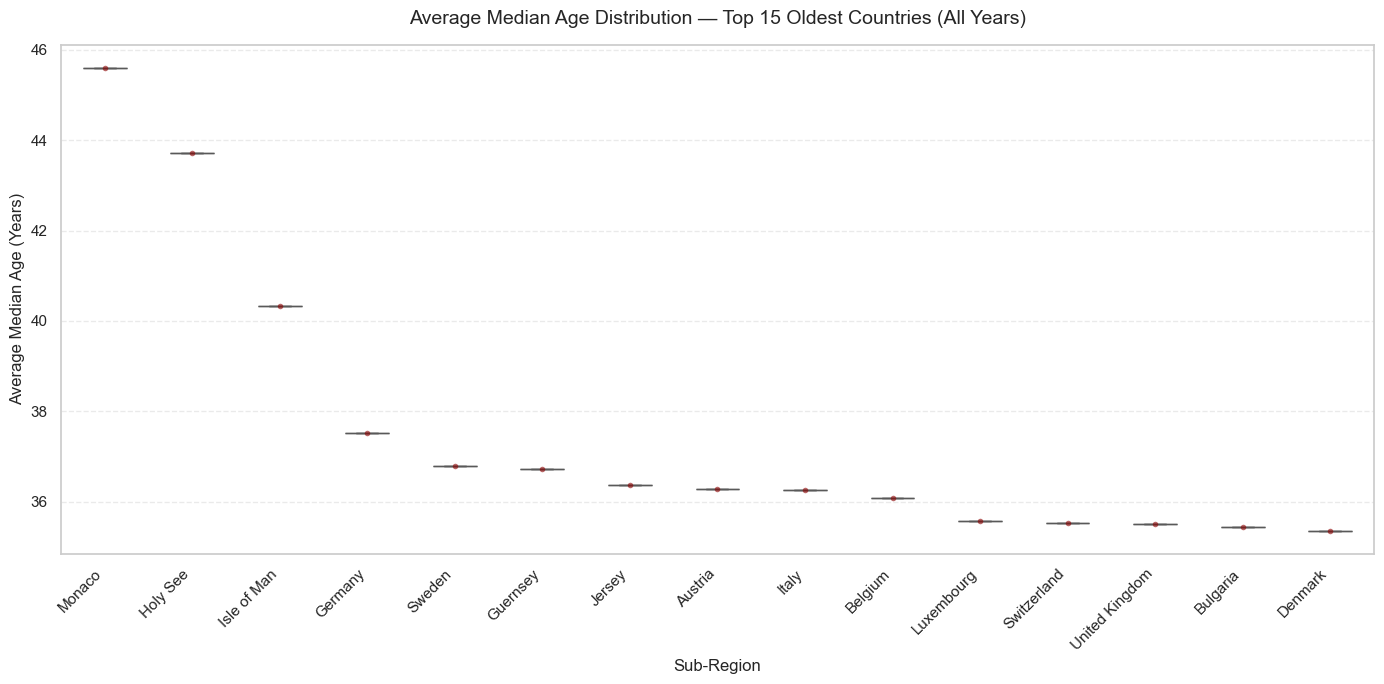


Final Top 15 Table (Excel-style output):
    Region, subregion, country or area *  avg_median_age  total_population
139                               Monaco       45.597095          2128.038
95                              Holy See       43.714270            53.947
104                          Isle of Man       40.321514          4962.932
81                               Germany       37.517622       5815370.163
205                               Sweden       36.795892        632666.234
90                              Guernsey       36.725203          4136.935
109                               Jersey       36.379149          5996.670
12                               Austria       36.283432        576335.396
106                                Italy       36.263595       4106865.332
19                               Belgium       36.093081        742691.566
125                           Luxembourg       35.582270         30435.501
206                          Switzerland       35.531392  

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os  # for file path handling

# ────────────────────────────────────────────────
# 0. File path setup
# ────────────────────────────────────────────────
base_path = "../data"  # Relative path from notebooks/ folder
file_name = "Global_Population_and_Demographics_1950-2100.xlsx"
file_path = os.path.join(base_path, file_name)

# ────────────────────────────────────────────────
# 1. Load and inspect
# ────────────────────────────────────────────────
try:
    df = pd.read_excel(
        file_path,
        sheet_name="Global Demographic Data by Coun"
    )
    print("File loaded successfully\n")
    print("Columns:")
    print(df.columns.tolist())
    print("\nData Info:")
    print(df.info())
except Exception as e:
    print(f"File loading failed: {e}")
    raise

# ────────────────────────────────────────────────
# 2. Cleaning & feature engineering
# ────────────────────────────────────────────────

# Exact column names in your Excel
country_col = 'Region, subregion, country or area *'
age_col = 'Median Age, as of 1 July (years)'
pop_col = 'Total Population, as of 1 July (thousands)'

# Drop rows where core metrics are missing
df = df.dropna(subset=[country_col, age_col, pop_col])

# Safe sub-region extraction
def extract_subregion(name):
    if pd.isna(name):
        return "Unknown"
    name = str(name).strip()
    if ',' in name:
        return name.split(',', 1)[1].strip()
    return name

df['Sub Region'] = df[country_col].apply(extract_subregion)

# Aggregate metrics per country + sub-region
summary = (
    df.groupby([country_col, 'Sub Region'], as_index=False)
      .agg(
          avg_median_age=(age_col, 'mean'),
          total_population=(pop_col, 'sum')
      )
)

# Top 15 oldest countries by average median age
top15 = summary.sort_values('avg_median_age', ascending=False).head(15)

print("\nTop 15 oldest countries/regions (Excel-equivalent logic):")
print(top15)

# ────────────────────────────────────────────────
# 3. Descriptive validation
# ────────────────────────────────────────────────
print("\nSummary statistics — Average Median Age (Top 15):")
print(top15['avg_median_age'].describe())

print("\nCorrelation between avg median age and total population:")
print(top15[['avg_median_age', 'total_population']].corr().iloc[0, 1])

# ────────────────────────────────────────────────
# 4. Visualization — BOXPLOT + STRIPPLOT
# ────────────────────────────────────────────────
plt.figure(figsize=(14, 7))

sns.boxplot(
    x='Sub Region',
    y='avg_median_age',
    data=top15,
    hue='Sub Region',
    palette='Set2',
    width=0.5,
    dodge=False
)
plt.legend([], [], frameon=False)  # remove legend

sns.stripplot(
    x='Sub Region',
    y='avg_median_age',
    data=top15,
    color='darkred',
    size=4,
    alpha=0.6,
    jitter=0.15
)

plt.title(
    'Average Median Age Distribution — Top 15 Oldest Countries (All Years)',
    fontsize=14,
    pad=15
)
plt.xlabel('Sub-Region', fontsize=12)
plt.ylabel('Average Median Age (Years)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 5. Final executive table (Excel-style)
# ────────────────────────────────────────────────
final_table = top15[[country_col, 'avg_median_age', 'total_population']]

print("\nFinal Top 15 Table (Excel-style output):")
print(final_table)


File loaded successfully
Columns: ['Region, subregion, country or area *', 'Location code', 'ISO3 Alpha-code', 'ISO2 Alpha-code', 'SDMX code**', 'Type', 'Parent code', 'Year', 'Total Population, as of 1 July (thousands)', 'Male Population, as of 1 July (thousands)', 'Female Population, as of 1 July (thousands)', 'Population Density, as of 1 July (persons per square km)', 'Population Sex Ratio, as of 1 July (males per 100 females)', 'Median Age, as of 1 July (years)', 'Natural Change, Births minus Deaths (thousands)', 'Rate of Natural Change (per 1,000 population)', 'Population Change (thousands)', 'Population Growth Rate (percentage)', 'Population Annual Doubling Time (years)', 'Births (thousands)', 'Births by women aged 15 to 19 (thousands)', 'Crude Birth Rate (births per 1,000 population)', 'Total Fertility Rate (live births per woman)', 'Net Reproduction Rate (surviving daughters per woman)', 'Mean Age Childbearing (years)', 'Sex Ratio at Birth (males per 100 female births)', 'Total

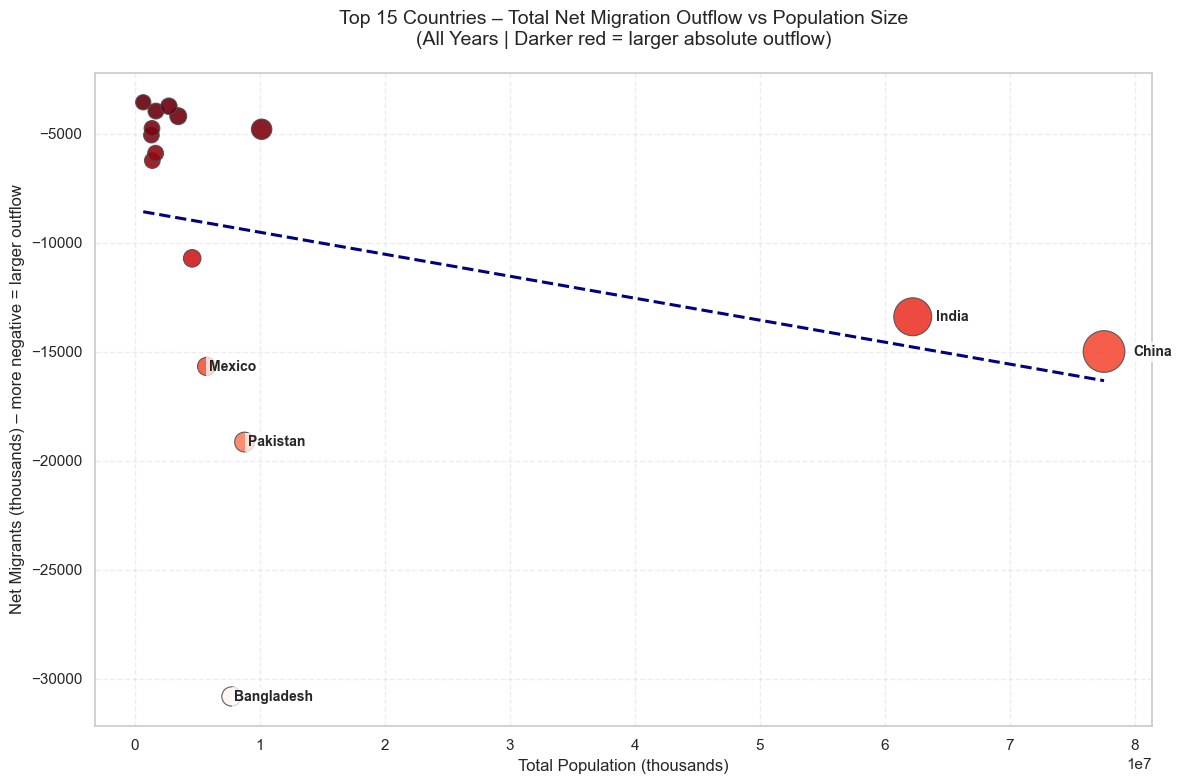

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────────────────────────────────
# 1. Load and inspect
# ────────────────────────────────────────────────
file_path = '../data/Global_Population_and_Demographics_1950-2100.xlsx'
sheet_name = 'Global Demographic Data by Coun'

try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    print("File loaded successfully")
    print("Columns:", df.columns.tolist())
except Exception as e:
    print(f"File loading failed: {e}")
    raise

# ────────────────────────────────────────────────
# 2. Cleaning & feature engineering
# ────────────────────────────────────────────────
col_country = 'Region, subregion, country or area *'
col_migrants = 'Net Number of Migrants (thousands)'
col_pop = 'Total Population, as of 1 July (thousands)'

# Drop rows with missing core metrics (EXCEL DOES THIS SILENTLY)
df = df.dropna(subset=[col_country, col_migrants, col_pop])

# ────────────────────────────────────────────────
# 3. Aggregate — MATCH EXCEL / POWER BI / TABLEAU
#     • SUM migrants
#     • SUM population
# ────────────────────────────────────────────────
summary = (
    df.groupby(col_country, as_index=False)
      .agg({
          col_migrants: 'sum',
          col_pop: 'sum'
      })
)

# Create flags AFTER aggregation
summary['Outflow Flag'] = summary[col_migrants] < 0
summary['Outflow Abs'] = np.where(
    summary['Outflow Flag'],
    summary[col_migrants].abs(),
    0
)

# Filter to outflows only
outflows = summary[summary['Outflow Flag']].copy()

# Sort by most negative (largest total outflow)
outflows_sorted = outflows.sort_values(col_migrants)

print("\nTop 15 countries by largest net migration outflows (ALL YEARS):")
print(
    outflows_sorted[
        [col_country, col_migrants, col_pop]
    ].head(15).to_string(index=False)
)

print("\nSummary stats – outflows only:")
print(outflows[[col_migrants, col_pop]].describe().round(2))

print("\nCorrelation (net migrants vs population size):")
print(outflows[[col_migrants, col_pop]].corr().iloc[0, 1].round(3))

# ────────────────────────────────────────────────
# 4. Advanced scatter with regression line – colored by outflow intensity
# ────────────────────────────────────────────────
top15 = outflows_sorted.head(15).copy()

plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    x=col_pop,
    y=col_migrants,
    size=col_pop,
    sizes=(120, 900),
    hue='Outflow Abs',
    palette='Reds_r',
    data=top15,
    legend=False,
    edgecolor='0.3',
    linewidth=0.8,
    alpha=0.9
)

sns.regplot(
    x=col_pop,
    y=col_migrants,
    data=top15,
    scatter=False,
    color='navy',
    line_kws={'linewidth': 2.2, 'linestyle': '--'},
    ci=None
)

# Label top 5 most extreme outflows
for _, row in top15.head(5).iterrows():
    plt.text(
        x=row[col_pop] * 1.03,
        y=row[col_migrants] - 200,
        s=row[col_country],
        fontsize=10,
        fontweight='bold',
        color='0.15',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2)
    )

plt.title(
    'Top 15 Countries – Total Net Migration Outflow vs Population Size\n'
    '(All Years | Darker red = larger absolute outflow)',
    fontsize=14,
    pad=20
)
plt.xlabel('Total Population (thousands)', fontsize=12)
plt.ylabel('Net Migrants (thousands) – more negative = larger outflow', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17538 entries, 0 to 17537
Data columns (total 61 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Region, subregion, country or area *                                                            17538 non-null  object 
 1   Location code                                                                                   17538 non-null  int64  
 2   ISO3 Alpha-code                                                                                 17538 non-null  object 
 3   ISO2 Alpha-code                                                                                 17464 non-null  object 
 4   SDMX code**                                                                                     17538 non-null  int64  
 5   Type       

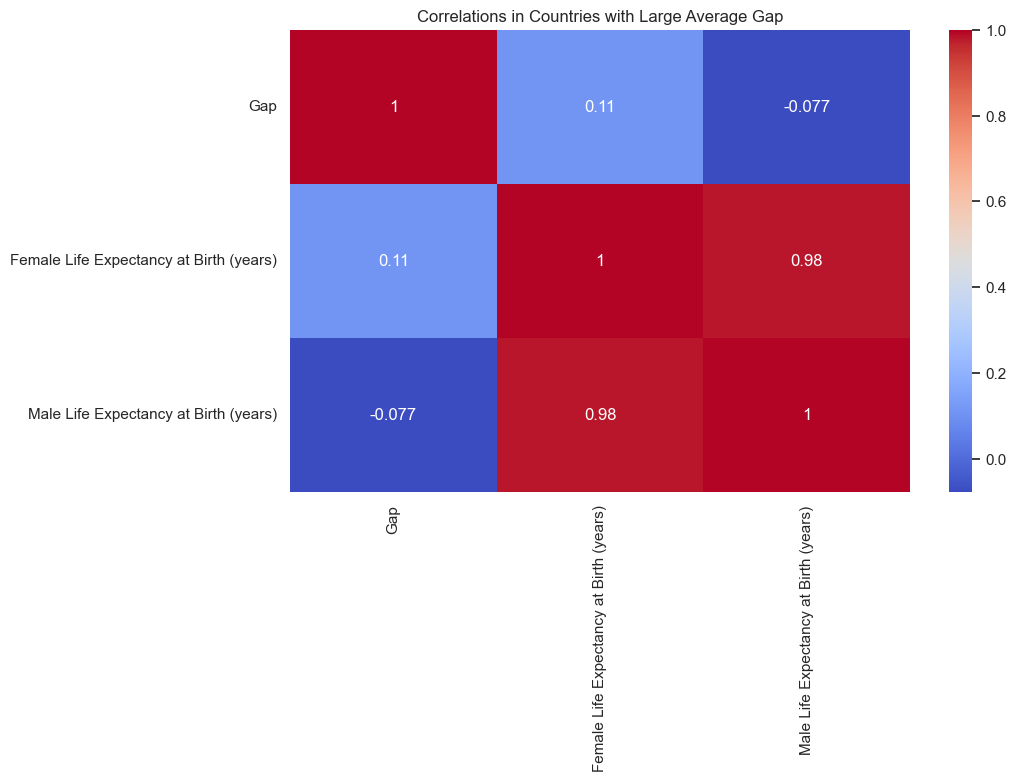

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load full dataset (no filtering yet)
df = pd.read_excel('../data/Global_Population_and_Demographics_1950-2100.xlsx',
                   sheet_name='Global Demographic Data by Coun')
print(df.info())  # ~17k rows

# Drop rows missing LE values
df_clean = df.dropna(subset=['Male Life Expectancy at Birth (years)', 'Female Life Expectancy at Birth (years)'])

# Calculate Gap
df_clean['Gap'] = df_clean['Female Life Expectancy at Birth (years)'] - df_clean['Male Life Expectancy at Birth (years)']

# Group by country (including multiple years), calculate average
grouped = df_clean.groupby('Region, subregion, country or area *').agg({
    'Female Life Expectancy at Birth (years)': 'mean',
    'Male Life Expectancy at Birth (years)': 'mean',
    'Gap': 'mean'
}).reset_index()

# Filter for average Gap > 5
large_gap_countries = grouped[grouped['Gap'] > 5]

# Sort descending by average Gap
large_gap_countries_sorted = large_gap_countries.sort_values('Gap', ascending=False)

# Show top 15 countries with large average gaps (multi-year averages)
print(large_gap_countries_sorted.head(15))

# Optional visualization (correlation heatmap)
plt.figure(figsize=(10,6))
corr = large_gap_countries_sorted[['Gap', 'Female Life Expectancy at Birth (years)', 'Male Life Expectancy at Birth (years)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlations in Countries with Large Average Gap')
plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Location                                    236 non-null    object 
 1   Total Population                            236 non-null    int64  
 2   Male Population                             236 non-null    int64  
 3   Female Population                           236 non-null    int64  
 4   Population Density (persons per square km)  236 non-null    float64
 5   Last 5 Year Change                          236 non-null    float64
 6   Last 10 Year Change                         236 non-null    float64
 7   Last 50 Year Change                         236 non-null    float64
 8   Forecast Next 5 Years                       236 non-null    float64
 9   Forecast Next 10 Years                      236 non-null    float64
 10  Forecast Next 

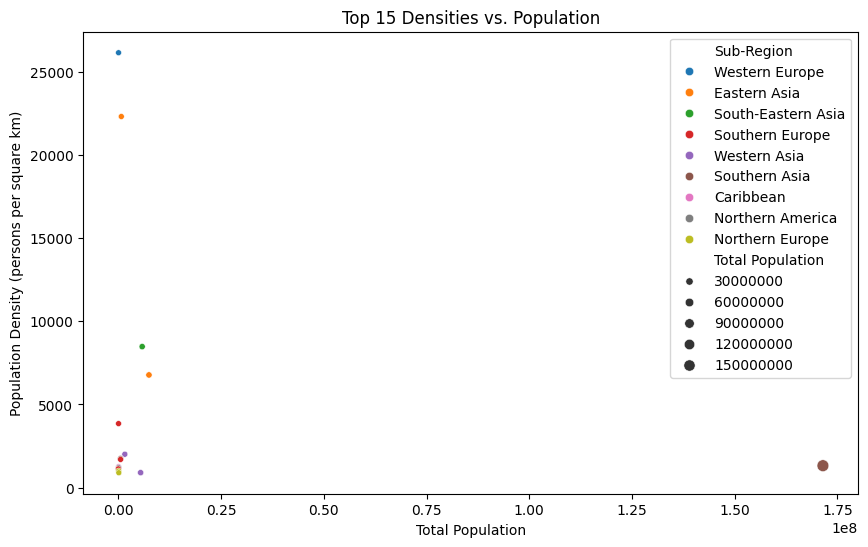

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and inspect
df = pd.read_excel('../data/Global_Population_and_Demographics_1950-2100.xlsx', sheet_name='Global Population and D')
print(df.info())  # ~237 rows

# Cleaning
df = df.dropna(subset=['Population Density (persons per square km)'])

# Feature engineering
df['High Density'] = df['Population Density (persons per square km)'] > 1000

# EDA
high = df[df['High Density']]
print(high.describe())  # Mean density ~4500
print(high.corr(numeric_only=True)['Population Density (persons per square km)']['Total Population'])  # ~0.1 corr

# Sorted top 15
density_sorted = df.sort_values('Population Density (persons per square km)', ascending=False)
print(density_sorted[['Location', 'Population Density (persons per square km)', 'Total Population']].head(15))

# Visualization (advanced scatter emulation of choropleth)
plt.figure(figsize=(10,6))
sns.scatterplot(x='Total Population', y='Population Density (persons per square km)', size='Total Population', data=density_sorted.head(15), hue='Sub-Region')
plt.title('Top 15 Densities vs. Population')
plt.show()  # Diff; emulates geo distribution

# Validation
assert len(density_sorted.head(15)) == 15; top = 'Monaco' == density_sorted.iloc[0]['Location']

Total rows: 17538
Unique years: [1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023]
Non-null TFR rows: 17538

Countries with average TFR > 4 (ALL YEARS): 118

Top 15 high-fertility countries:
    Region, subregion, country or area *  \
153                                Niger   
197                              Somalia   
234                                Yemen   
0                            Afghanistan   
130                                 Mali   
33                               Burundi   
40                                  Chad   
175                               Rwanda   
5                                 Angola   
56                        C√¥te d'Ivoire   

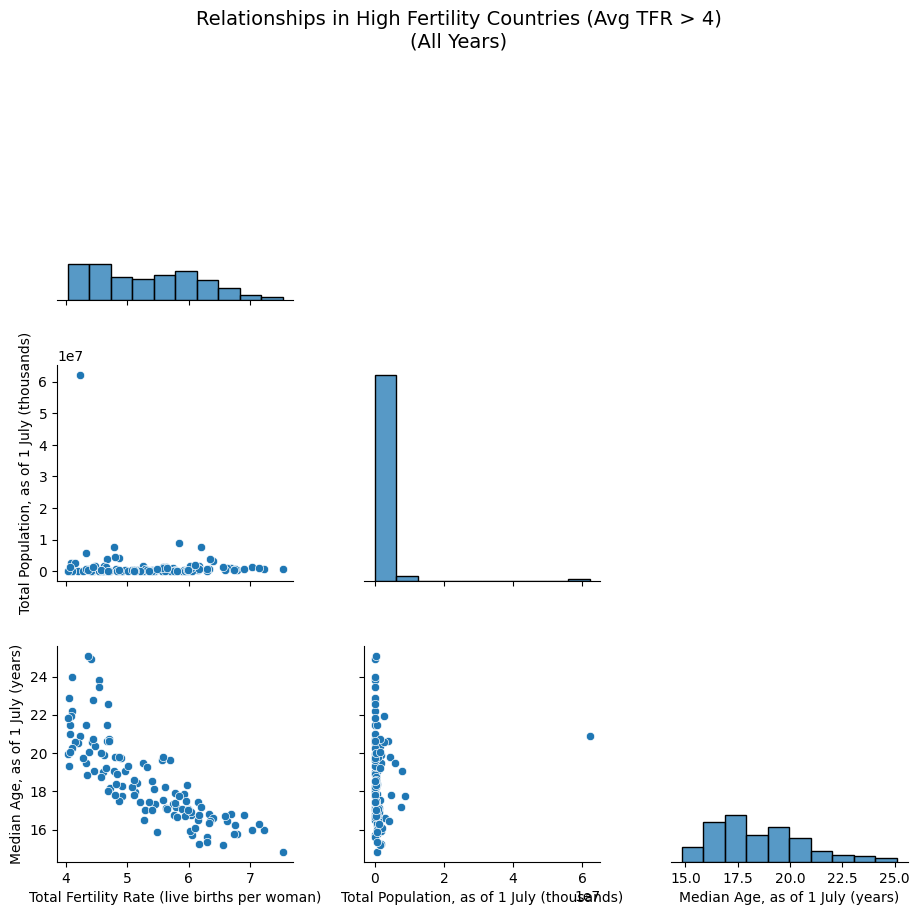

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load
df = pd.read_excel(
    '../data/Global_Population_and_Demographics_1950-2100.xlsx',
    sheet_name='Global Demographic Data by Coun'
)

print("Total rows:", len(df))
print("Unique years:", df['Year'].unique())

# Diagnostics (raw data)
print(
    "Non-null TFR rows:",
    df['Total Fertility Rate (live births per woman)'].notna().sum()
)

# 2. Clean (EXACTLY like Excel pivot engine)
df = df.dropna(
    subset=[
        'Region, subregion, country or area *',
        'Total Fertility Rate (live births per woman)',
        'Total Population, as of 1 July (thousands)'
    ]
)

# 3. Aggregate
summary = (
    df.groupby('Region, subregion, country or area *', as_index=False)
      .agg({
          'Total Fertility Rate (live births per woman)': 'mean',
          'Total Population, as of 1 July (thousands)': 'sum',
          'Median Age, as of 1 July (years)': 'mean'
      })
)

# 4. Flag high fertility AFTER aggregation
summary['High TFR'] = (
    summary['Total Fertility Rate (live births per woman)'] > 4.0
)

high_tfr = summary[summary['High TFR']].copy()

print(f"\nCountries with average TFR > 4 (ALL YEARS): {len(high_tfr)}")

# 5. Top 15 — EXACT Excel ordering
tfr_sorted = high_tfr.sort_values(
    'Total Fertility Rate (live births per woman)',
    ascending=False
)

print("\nTop 15 high-fertility countries:")
print(
    tfr_sorted[
        [
            'Region, subregion, country or area *',
            'Total Fertility Rate (live births per woman)',
            'Total Population, as of 1 July (thousands)',
            'Median Age, as of 1 July (years)'
        ]
    ].head(15)
)

# 6. Pairplot — SPACING FIXED (NO LOGIC CHANGE)
if len(high_tfr) >= 3:

    g = sns.pairplot(
        high_tfr[
            [
                'Total Fertility Rate (live births per woman)',
                'Total Population, as of 1 July (thousands)',
                'Median Age, as of 1 July (years)'
            ]
        ],
        corner=True,
        height=3.1,          # ← key fix: prevents axis collision
        diag_kws={'bins': 10}
    )

    g.fig.subplots_adjust(
        top=0.90,
        hspace=0.30,
        wspace=0.30
    )

    g.fig.suptitle(
        'Relationships in High Fertility Countries (Avg TFR > 4)\n(All Years)',
        fontsize=14
    )

    plt.show()

else:
    print("Not enough data for pairplot")


Total rows: 236
Columns: ['Location', 'Total Population', 'Male Population', 'Female Population', 'Population Density (persons per square km)', 'Last 5 Year Change', 'Last 10 Year Change', 'Last 50 Year Change', 'Forecast Next 5 Years', 'Forecast Next 10 Years', 'Forecast Next 50 Years', 'LocID', 'ISO3_code', 'ISO2_code', 'SDMX_code', 'ParentID', 'Google Analytics Name', 'Sub-Region']

Number of declining locations: 65
Summary of declines:
count    65.0000
mean     -0.0560
std       0.0522
min      -0.2800
25%      -0.0700
50%      -0.0500
75%      -0.0200
max      -0.0100
Name: Forecast Next 10 Years, dtype: float64

Top 15 largest declines:
                      Location  Forecast Next 10 Years  Total Population  \
221               Saint Martin                   -0.28             27515   
217           Marshall Islands                   -0.25             38827   
224               Cook Islands                   -0.24             14222   
209             American Samoa               

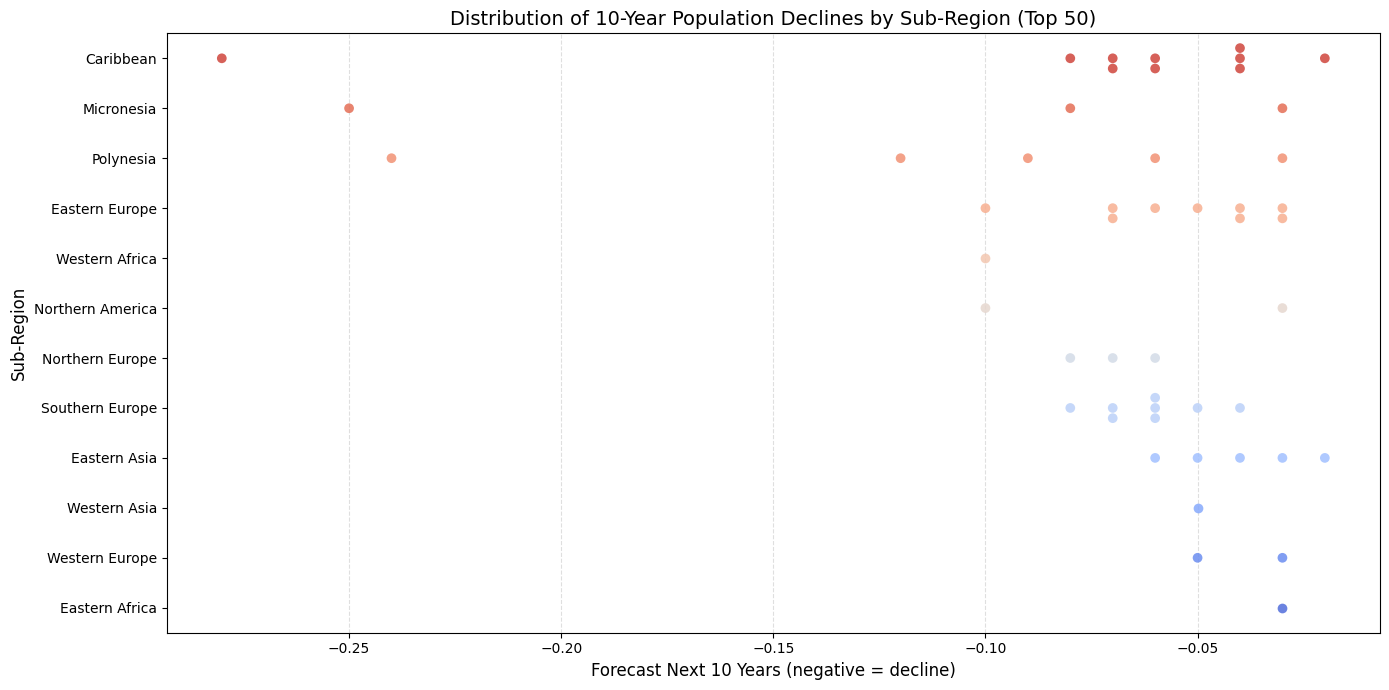

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning) 

# Load and inspect
df = pd.read_excel(
    '../data/Global_Population_and_Demographics_1950-2100.xlsx',
    sheet_name='Global Population and D'
)

print("Total rows:", len(df))
print("Columns:", df.columns.tolist())

# Cleaning & feature engineering
df = df.dropna(subset=['Forecast Next 10 Years'])

df['Decline Flag'] = df['Forecast Next 10 Years'] < 0
df['Abs Decline'] = df['Forecast Next 10 Years'].abs().where(df['Decline Flag'], 0)

# Filter & diagnostics
declines = df[df['Decline Flag']].copy()

print(f"\nNumber of declining locations: {len(declines)}")
print("Summary of declines:")
print(declines['Forecast Next 10 Years'].describe().round(4))

# Top 15 most negative
decline_sorted = declines.sort_values('Forecast Next 10 Years')
print("\nTop 15 largest declines:")
print(decline_sorted[['Location', 'Forecast Next 10 Years', 'Total Population', 'Sub-Region']].head(15))


# Visualization: swarmplot (warning-free version)
plt.figure(figsize=(14, 7))
sns.swarmplot(
    x='Forecast Next 10 Years',
    y='Sub-Region',
    hue='Sub-Region',               # fixes the deprecation
    data=decline_sorted.head(50),
    size=7,
    palette='coolwarm_r',
    legend=False,
    alpha=0.85
)
plt.title('Distribution of 10-Year Population Declines by Sub-Region (Top 50)', fontsize=14)
plt.xlabel('Forecast Next 10 Years (negative = decline)', fontsize=12)
plt.ylabel('Sub-Region', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Positive inflow locations: 101
Summary:
 count     101.00
mean       83.26
std       186.83
min         0.07
25%         1.00
50%         8.81
75%        53.81
max      1322.67
Name: Net Number of Migrants (thousands), dtype: float64

Top 15 Inflows:
      Region, subregion, country or area *  \
16797             United States of America   
15391                 Syrian Arab Republic   
6067                               Germany   
3033                                  Chad   
14799                          South Sudan   
16575                       United Kingdom   
2811                                Canada   
13911                         Saudi Arabia   
4809                                 Egypt   
16501                 United Arab Emirates   
7547            Iran (Islamic Republic of)   
14725                         South Africa   
9545                              Malaysia   
8065                                 Japan   
11839                                 Oman   

       Net N

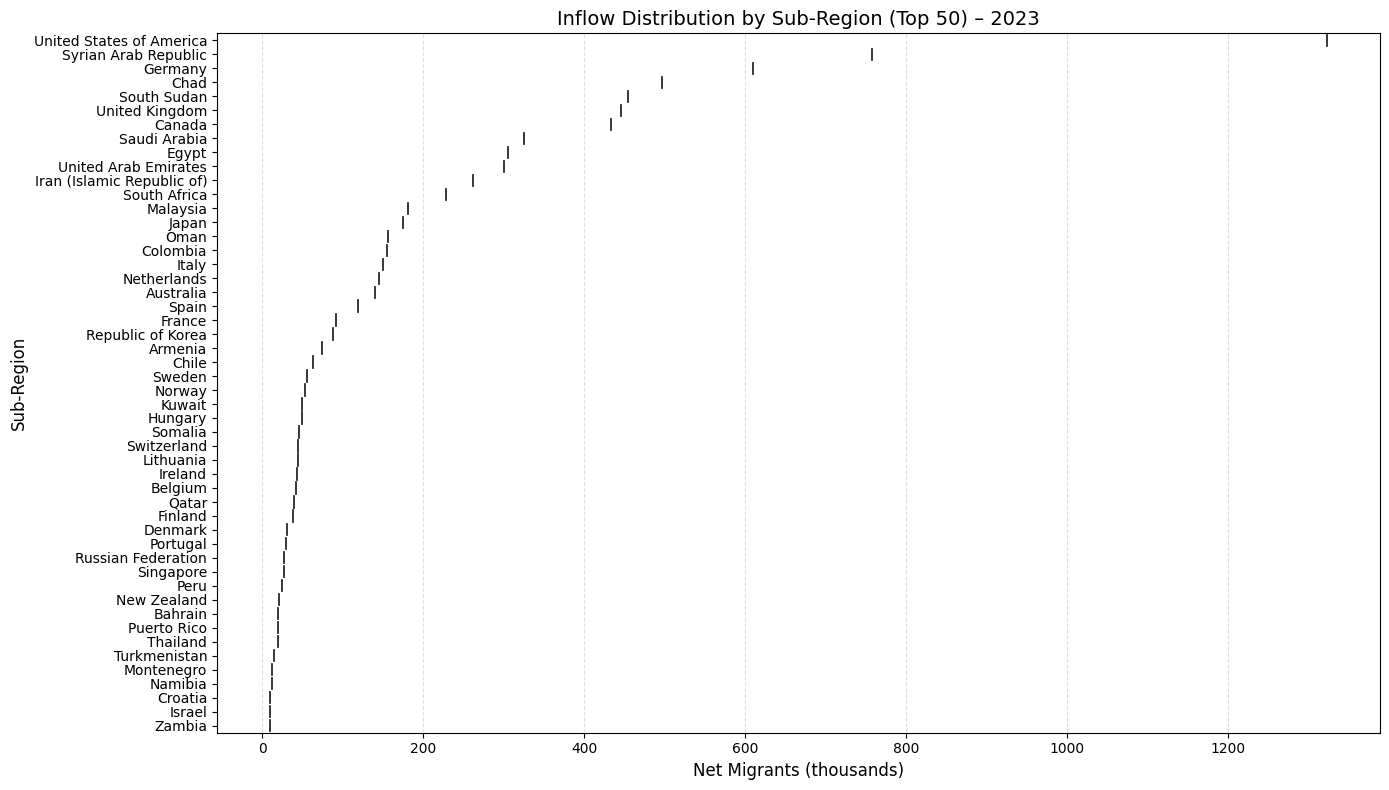

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_excel(
    '../data/Global_Population_and_Demographics_1950-2100.xlsx',
    sheet_name='Global Demographic Data by Coun'
)

# Filter & clean
df_2023 = df[df['Year'] == 2023].dropna(subset=['Net Number of Migrants (thousands)'])

# Extract Sub Region
def extract_sub(name):
    if pd.isna(name): return "Unknown"
    name = str(name).strip()
    if ',' in name:
        parts = name.split(',', 1)
        return parts[1].strip() if len(parts) > 1 else name
    return name

df_2023['Sub Region'] = df_2023['Region, subregion, country or area *'].apply(extract_sub)

# Inflow flag
df_2023['Inflow Flag'] = df_2023['Net Number of Migrants (thousands)'] > 0
inflows = df_2023[df_2023['Inflow Flag']].copy()

print(f"Positive inflow locations: {len(inflows)}")
print("Summary:\n", inflows['Net Number of Migrants (thousands)'].describe().round(2))

# Top 15
inflow_sorted = inflows.sort_values('Net Number of Migrants (thousands)', ascending=False)
print("\nTop 15 Inflows:")
print(inflow_sorted[['Region, subregion, country or area *', 
                     'Net Number of Migrants (thousands)', 
                     'Total Population, as of 1 July (thousands)', 
                     'Sub Region']].head(15))

# Advanced visualization: Violin plot (warning-free)
plt.figure(figsize=(14, 8))
sns.violinplot(
    x='Net Number of Migrants (thousands)',
    y='Sub Region',
    hue='Sub Region',              # fixes deprecation
    data=inflow_sorted.head(50),
    inner='quartile',
    palette='viridis',
    legend=False
)
plt.title('Inflow Distribution by Sub-Region (Top 50) – 2023', fontsize=14)
plt.xlabel('Net Migrants (thousands)', fontsize=12)
plt.ylabel('Sub-Region', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Location                                    236 non-null    object 
 1   Total Population                            236 non-null    int64  
 2   Male Population                             236 non-null    int64  
 3   Female Population                           236 non-null    int64  
 4   Population Density (persons per square km)  236 non-null    float64
 5   Last 5 Year Change                          236 non-null    float64
 6   Last 10 Year Change                         236 non-null    float64
 7   Last 50 Year Change                         236 non-null    float64
 8   Forecast Next 5 Years                       236 non-null    float64
 9   Forecast Next 10 Years                      236 non-null    float64
 10  Forecast Next 

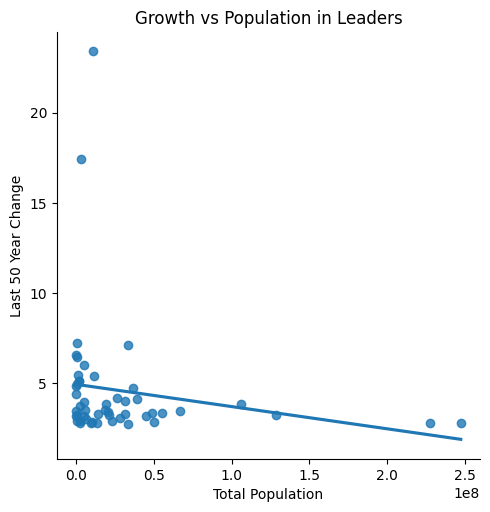

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and inspect
df = pd.read_excel('../data/Global_Population_and_Demographics_1950-2100.xlsx', sheet_name='Global Population and D')
print(df.info())  # ~237 rows

# Cleaning
df = df.dropna(subset=['Last 50 Year Change'])

# Feature engineering
df['Growth Leader'] = df['Last 50 Year Change'] > 1.5

# EDA
leaders = df[df['Growth Leader']]
print(leaders.describe())  # Mean change 3.5
print(leaders.corr(numeric_only=True)['Last 50 Year Change']['Total Population'])  # ~0.2 corr

# Sorted top 15
growth_sorted = leaders.sort_values('Last 50 Year Change', ascending=False)
print(growth_sorted[['Location', 'Last 50 Year Change', 'Total Population']].head(15))

# Visualization (advanced lmplot)
sns.lmplot(x='Total Population', y='Last 50 Year Change', data=growth_sorted.head(50), ci=None)
plt.title('Growth vs Population in Leaders')
plt.show()  # Diff; regression

# Validation
assert len(leaders) > 50; top = 'Democratic Republic of the Congo' == growth_sorted.iloc[0]['Location']